In [3]:
pip install pylops

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


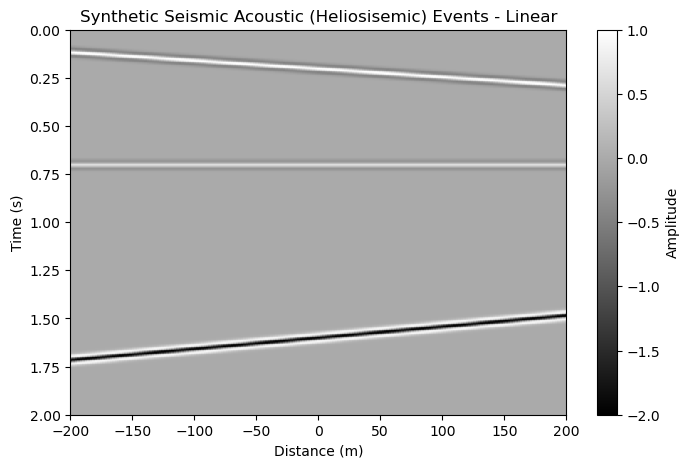

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pylops

# Parameters for seismic events
par = {
    "ox": -200,      # origin x
    "dx": 2,         # delta x
    "nx": 201,       # number of x samples
    "oy": -100,      # origin y
    "dy": 2,         # delta y
    "ny": 101,       # number of y samples
    "ot": 0,         # origin time
    "dt": 0.004,     # time sampling interval
    "nt": 501,       # number of time samples
    "f0": 20,        # central frequency of wavelet
    "nfmax": 210     # max frequency number
}

# Create time and space axes
t, t2, x, y = pylops.utils.seismicevents.makeaxis(par)

# Create a Ricker wavelet
wav = pylops.utils.wavelets.ricker(np.arange(41) * par["dt"], f0=par["f0"])[0]

# Define seismic event parameters
v = 1500        # velocity in m/s
t0 = [0.2, 0.7, 1.6]   # event start times (s)
theta = [40, 0, -60]   # angles (degrees)
amp = [1.0, 0.6, -2.0] # amplitudes

# Generate 2D linear seismic events with wavelet
mlin, mlinwav = pylops.utils.seismicevents.linear2d(x, t, v, t0, theta, amp, wav)

# Plot the synthesized seismic acoustic events
plt.figure(figsize=(8,5))
plt.imshow(mlinwav.T, aspect="auto", interpolation="nearest", cmap="gray",
           extent=(x.min(), x.max(), t.max(), t.min()))
plt.title("Synthetic Seismic Acoustic (Heliosisemic) Events - Linear")
plt.xlabel("Distance (m)")
plt.ylabel("Time (s)")
plt.colorbar(label='Amplitude')
plt.show()

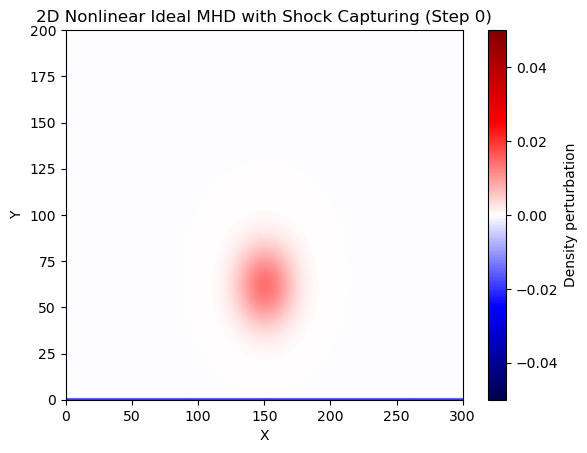

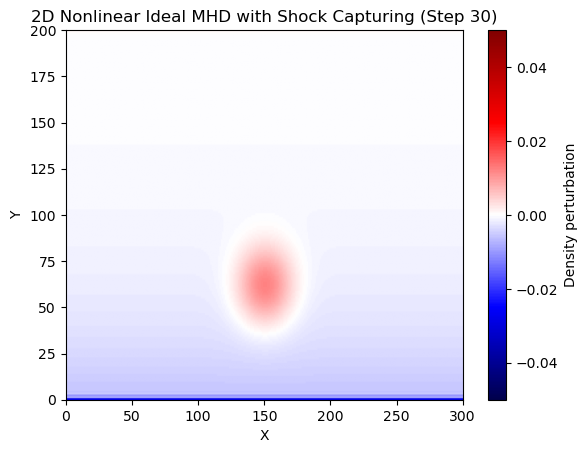

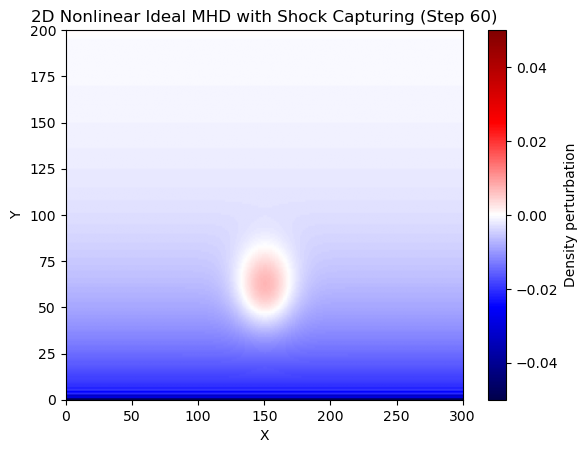

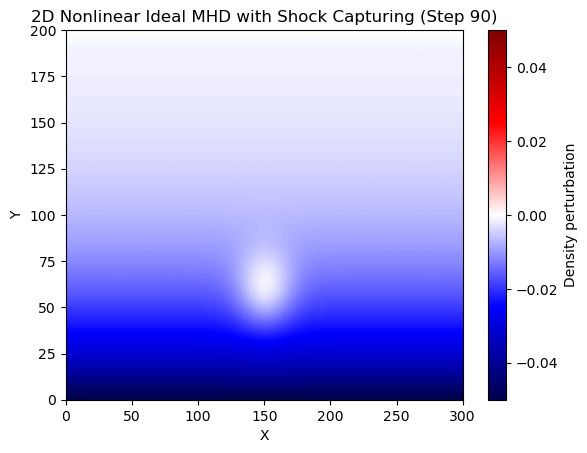

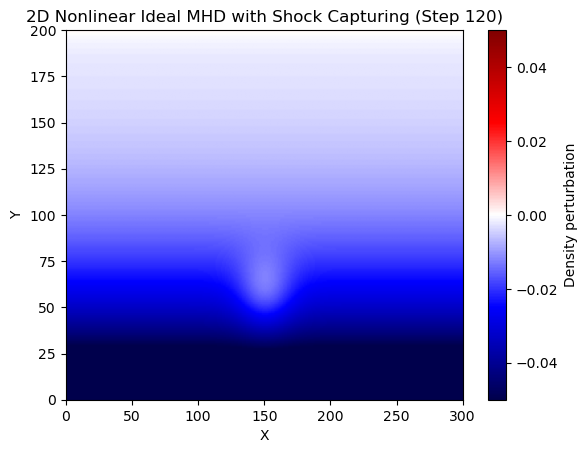

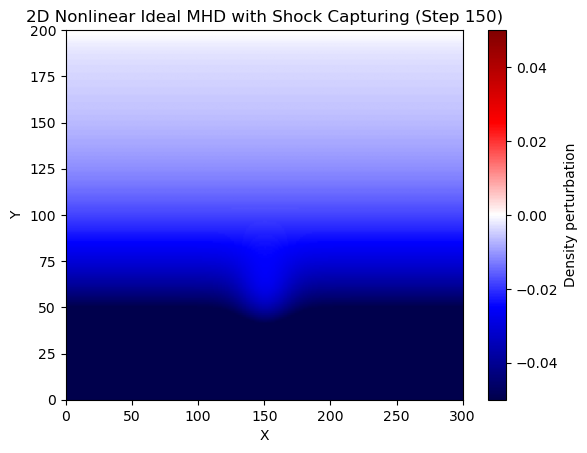

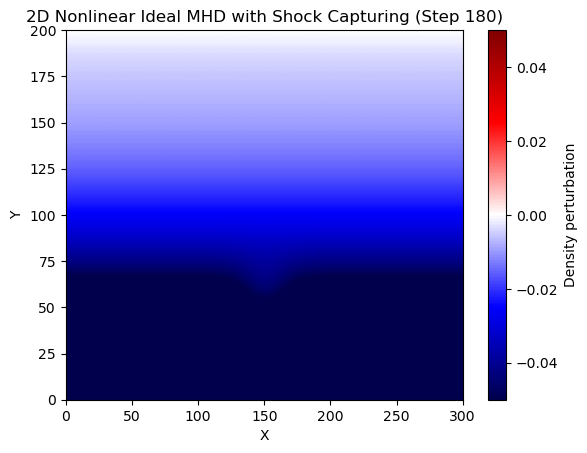

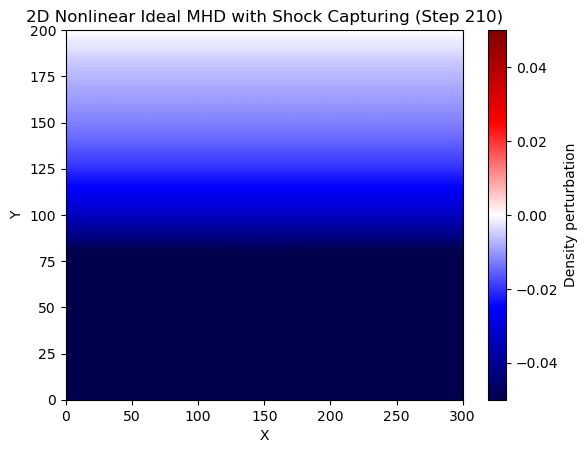

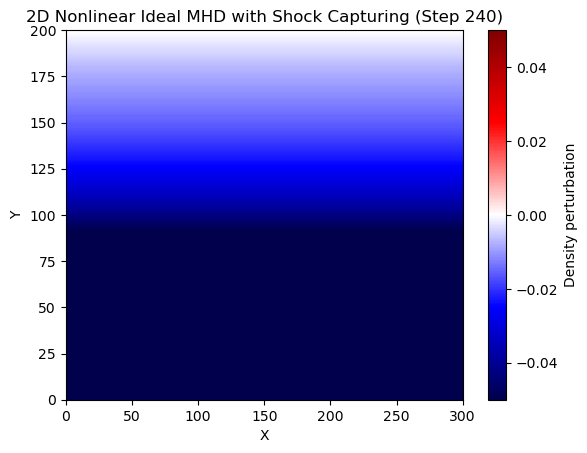

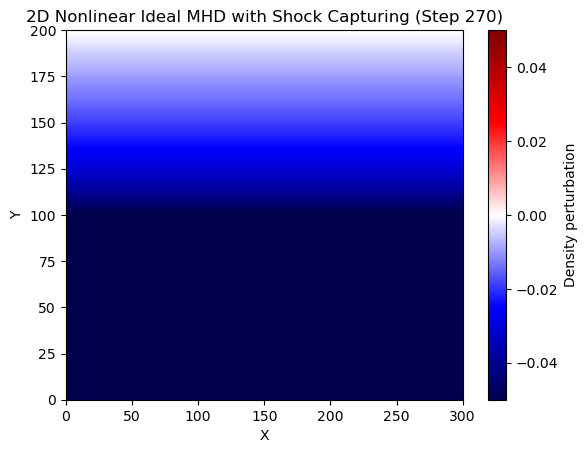

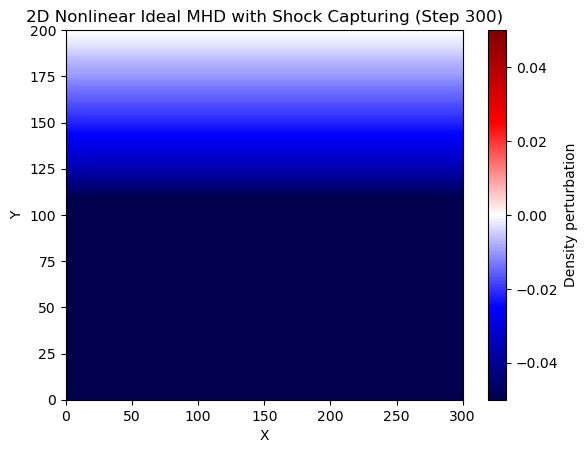

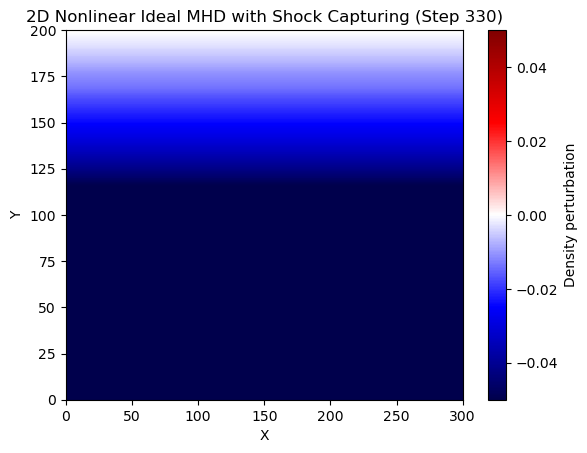

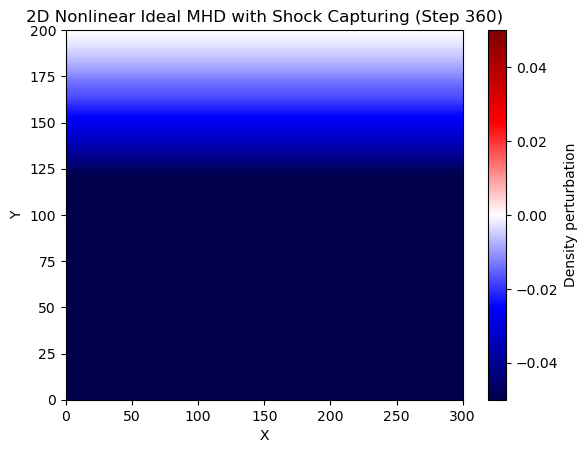

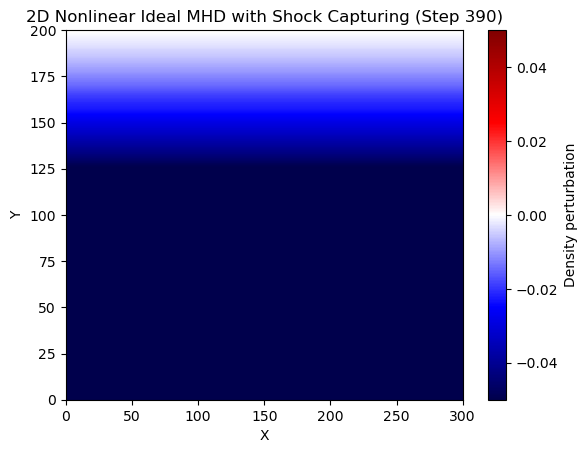

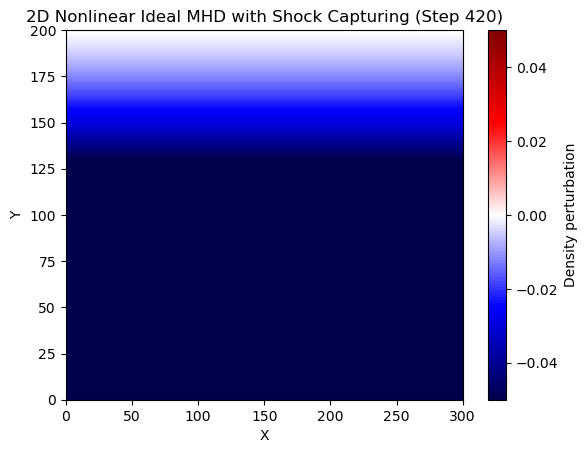

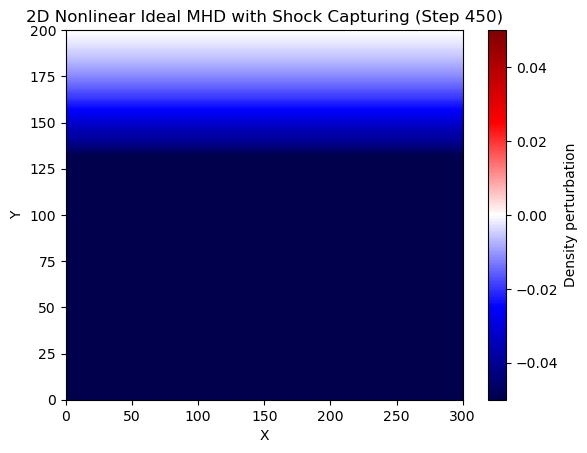

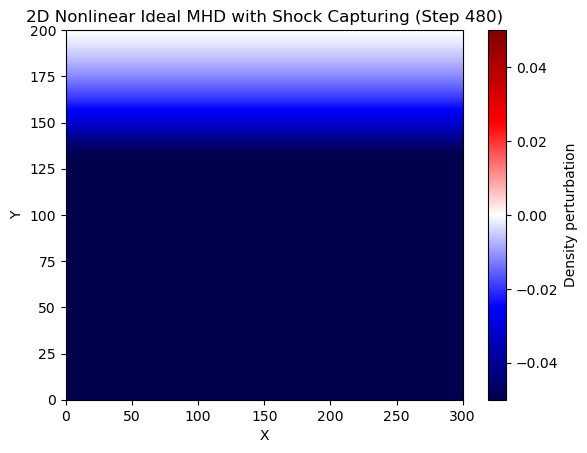

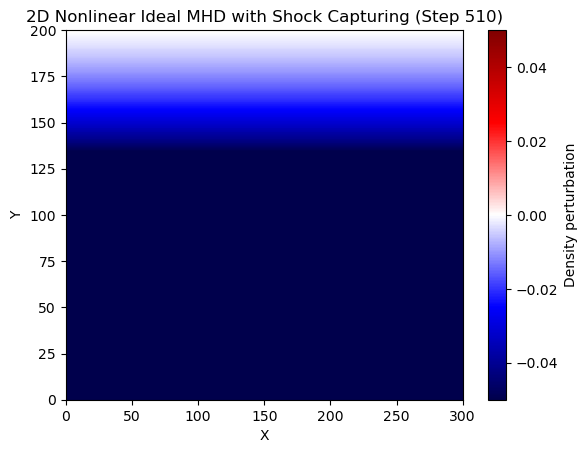

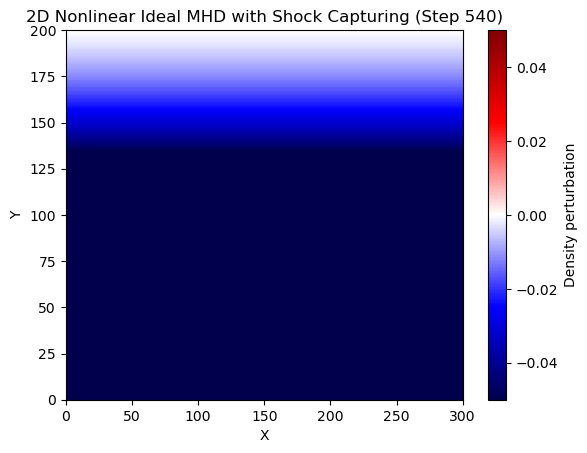

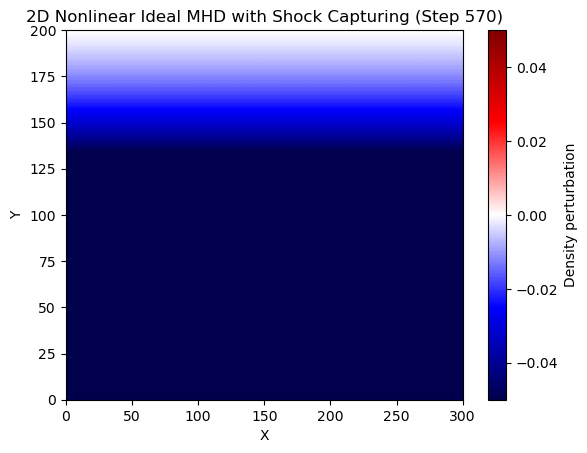

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Parameters and constants
# ----------------------------------------
nx, ny = 300, 200
dx, dy = 1.0, 1.0
dt = 0.05   # smaller dt for increased stability with RK3
nt = 600

g = 0.274       # gravity
gamma = 5/3     # adiabatic index
mu0 = 1.0       # magnetic permeability
eta = 0.005     # resistivity (magnetic diffusivity)
nu = 0.005      # viscosity (kinematic)

# Background magnetic field
B0x, B0y = 0.05, 0.1

# ----------------------------------------
# Grid and background atmosphere
# ----------------------------------------
y = np.arange(ny) * dy
rho0 = np.exp(-y / 50.0)
p0 = rho0  # isothermal background pressure

# Initialize primitive variables (with perturbation)
rho = rho0[np.newaxis, :] * (1 + 0.05 * np.exp(-((np.arange(nx)[:, None]-nx//2)**2 + (np.arange(ny)[None,:]-ny//3)**2)/(2*15**2)))
vx = np.zeros((nx, ny))
vy = np.zeros((nx, ny))
bx = np.zeros((nx, ny))
by = np.zeros((nx, ny))
energy = p0[np.newaxis, :] / (gamma - 1)  # internal energy

# ----------------------------------------
# Finite difference operators
# ----------------------------------------
def ddx(f):
    return (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2*dx)

def ddy(f):
    df = np.zeros_like(f)
    df[:, 1:-1] = (f[:, 2:] - f[:, :-2]) / (2*dy)
    df[:, 0] = (f[:, 1] - f[:, 0]) / dy
    df[:, -1] = (f[:, -1] - f[:, -2]) / dy
    return df

def div(vx, vy):
    return ddx(vx) + ddy(vy)

def laplacian(f):
    return (np.roll(f, -1, axis=0) + np.roll(f, 1, axis=0) +
            np.roll(f, -1, axis=1) + np.roll(f, 1, axis=1) - 4 * f) / (dx * dy)

# ----------------------------------------
# Minmod slope limiter for shock capturing
# ----------------------------------------
def minmod(a, b):
    return np.where(np.abs(a) < np.abs(b), np.where(a*b > 0, a, 0), np.where(a*b > 0, b, 0))

def slope_limiter(f):
    df_x1 = f - np.roll(f, 1, axis=0)
    df_x2 = np.roll(f, -1, axis=0) - f
    df_x = minmod(df_x1, df_x2)

    df_y1 = f - np.roll(f, 1, axis=1)
    df_y2 = np.roll(f, -1, axis=1) - f
    df_y = minmod(df_y1, df_y2)

    return df_x, df_y

# ----------------------------------------
# Functions for fluxes and time derivatives
# ----------------------------------------
def total_Bx():
    return B0x + bx

def total_By():
    return B0y + by

def total_pressure(rho, energy, bx, by):
    p_gas = (gamma - 1) * energy
    b2 = total_Bx()**2 + total_By()**2
    p_mag = b2 / (2 * mu0)
    return p_gas + p_mag

def compute_rhs(rho, vx, vy, bx, by, energy):
    Bx = total_Bx()
    By = total_By()

    # Apply slope limiter for shock capturing on velocities and fields
    dvx_dx, dvx_dy = slope_limiter(vx)
    dvy_dx, dvy_dy = slope_limiter(vy)
    dbx_dx, dbx_dy = slope_limiter(bx)
    dby_dx, dby_dy = slope_limiter(by)
    drho_dx, drho_dy = slope_limiter(rho)
    denergy_dx, denergy_dy = slope_limiter(energy)

    # Compute derivatives with finite differences
    dvrx = ddx(vx)
    dvry = ddy(vy)

    # Current density (J = curl B / mu0)
    Jz = (ddy(Bx) - ddx(By)) / mu0

    # Lorentz forces
    Fx = Jz * By
    Fy = -Jz * Bx

    # Gas pressure
    p_gas = (gamma - 1) * energy
    dp_dx = ddx(p_gas)
    dp_dy = ddy(p_gas)

    # Momentum derivatives (including viscosity)
    dvx_dt = -(vx * ddx(vx) + vy * ddy(vx)) - (1 / rho) * dp_dx + Fx / rho + nu * laplacian(vx)
    dvy_dt = -(vx * ddx(vy) + vy * ddy(vy)) - (1 / rho) * dp_dy + Fy / rho - g + nu * laplacian(vy)

    # Induction equations with resistivity and slope-limited terms
    dbx_dt = ddx(vx * By - vy * Bx) + eta * laplacian(bx)
    dby_dt = ddy(vx * By - vy * Bx) + eta * laplacian(by)

    # Continuity equation
    drho_dt = -div(vx * rho, vy * rho)

    # Energy equation with viscous and resistive heating terms
    div_v = div(vx, vy)
    magnetic_work = (Bx * dbx_dt + By * dby_dt) / mu0
    viscous_heating = nu * ( (ddx(vx))**2 + (ddy(vy))**2 )
    de_dt = -(div((energy + p_gas) * vx, (energy + p_gas) * vy)) + magnetic_work + viscous_heating

    return drho_dt, dvx_dt, dvy_dt, dbx_dt, dby_dt, de_dt

# ----------------------------------------
# Runge-Kutta 3rd order time integration
# ----------------------------------------
def rk3_step(rho, vx, vy, bx, by, energy, dt):
    drho1, dvx1, dvy1, dbx1, dby1, de1 = compute_rhs(rho, vx, vy, bx, by, energy)
    r1 = rho + dt * drho1
    vx1 = vx + dt * dvx1
    vy1 = vy + dt * dvy1
    bx1 = bx + dt * dbx1
    by1 = by + dt * dby1
    en1 = energy + dt * de1

    drho2, dvx2, dvy2, dbx2, dby2, de2 = compute_rhs(r1, vx1, vy1, bx1, by1, en1)
    r2 = 0.75 * rho + 0.25 * (r1 + dt * drho2)
    vx2 = 0.75 * vx + 0.25 * (vx1 + dt * dvx2)
    vy2 = 0.75 * vy + 0.25 * (vy1 + dt * dvy2)
    bx2 = 0.75 * bx + 0.25 * (bx1 + dt * dbx2)
    by2 = 0.75 * by + 0.25 * (by1 + dt * dby2)
    en2 = 0.75 * energy + 0.25 * (en1 + dt * de2)

    drho3, dvx3, dvy3, dbx3, dby3, de3 = compute_rhs(r2, vx2, vy2, bx2, by2, en2)
    rho_new = (1/3) * rho + (2/3) * (r2 + dt * drho3)
    vx_new = (1/3) * vx + (2/3) * (vx2 + dt * dvx3)
    vy_new = (1/3) * vy + (2/3) * (vy2 + dt * dvy3)
    bx_new = (1/3) * bx + (2/3) * (bx2 + dt * dbx3)
    by_new = (1/3) * by + (2/3) * (by2 + dt * dby3)
    energy_new = (1/3) * energy + (2/3) * (en2 + dt * de3)

    return rho_new, vx_new, vy_new, bx_new, by_new, energy_new

# ----------------------------------------
# Boundary conditions: Open boundaries with zero-gradient
# ----------------------------------------
def apply_boundary(f):
    f[0, :] = f[1, :]
    f[-1, :] = f[-2, :]
    f[:, 0] = f[:, 1]
    f[:, -1] = f[:, -2]
    return f

# ----------------------------------------
# Main time-stepping loop
# ----------------------------------------
plt.ion()
for n in range(nt):
    rho, vx, vy, bx, by, energy = rk3_step(rho, vx, vy, bx, by, energy, dt)

    # Apply open boundary conditions
    rho = apply_boundary(rho)
    vx = apply_boundary(vx)
    vy = apply_boundary(vy)
    bx = apply_boundary(bx)
    by = apply_boundary(by)
    energy = apply_boundary(energy)

    # Visualization every 30 steps
    if n % 30 == 0:
        plt.clf()
        density_perturb = rho - rho0[np.newaxis, :]
        plt.imshow(density_perturb.T, origin='lower', cmap='seismic', vmin=-0.05, vmax=0.05,
                   extent=[0, nx*dx, 0, ny*dy], aspect='auto')
        plt.colorbar(label='Density perturbation')
        plt.title(f'2D Nonlinear Ideal MHD with Shock Capturing (Step {n})')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.pause(0.01)

plt.ioff()
plt.show()

Solar MHD Simulation Starting
Grid: 128 x 128 x 64
Domain: 6.0 x 6.0 x 1.4 Mm
Resolution: 46.9 x 46.9 x 21.9 km
t =    120.0 s  |  Step    376
  ρ: [5.92e-06, 2.18e-01] kg/m³
  |v|: [16332.0, 18617.9] m/s
  |B|: [5.2, 215.6] G


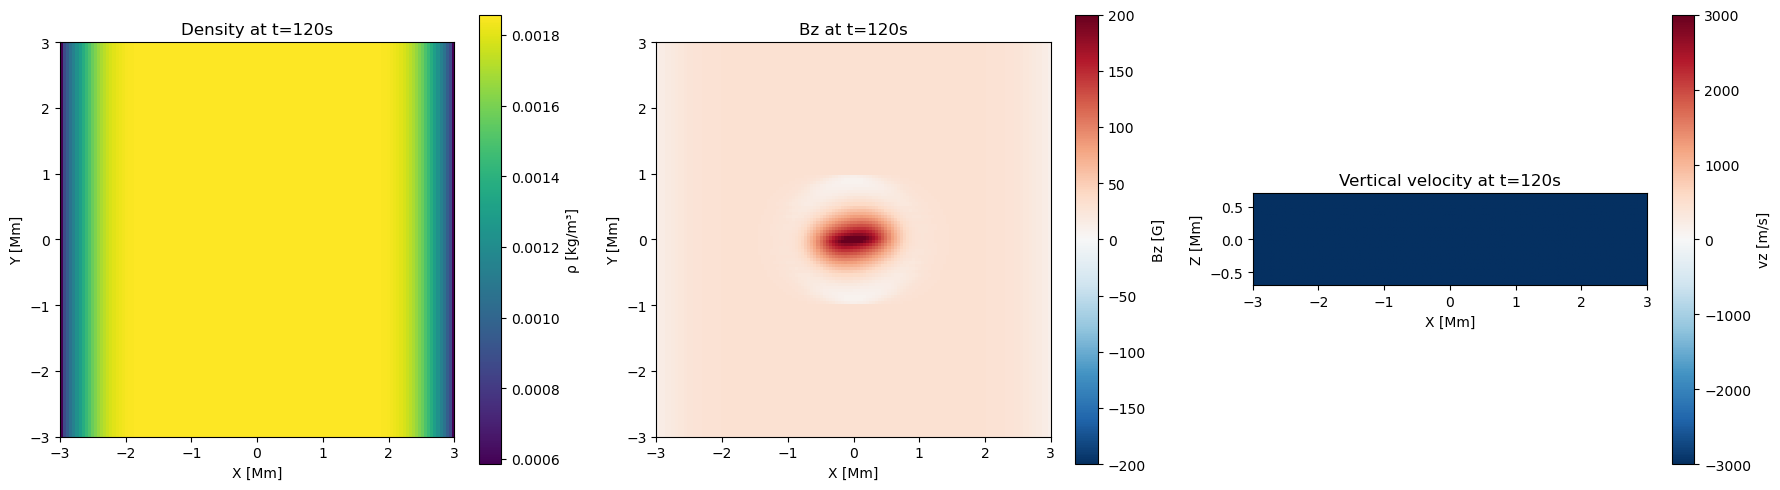

t =    240.0 s  |  Step    833
  ρ: [4.88e-06, 2.20e-01] kg/m³
  |v|: [29207.1, 33602.8] m/s
  |B|: [5.2, 215.3] G


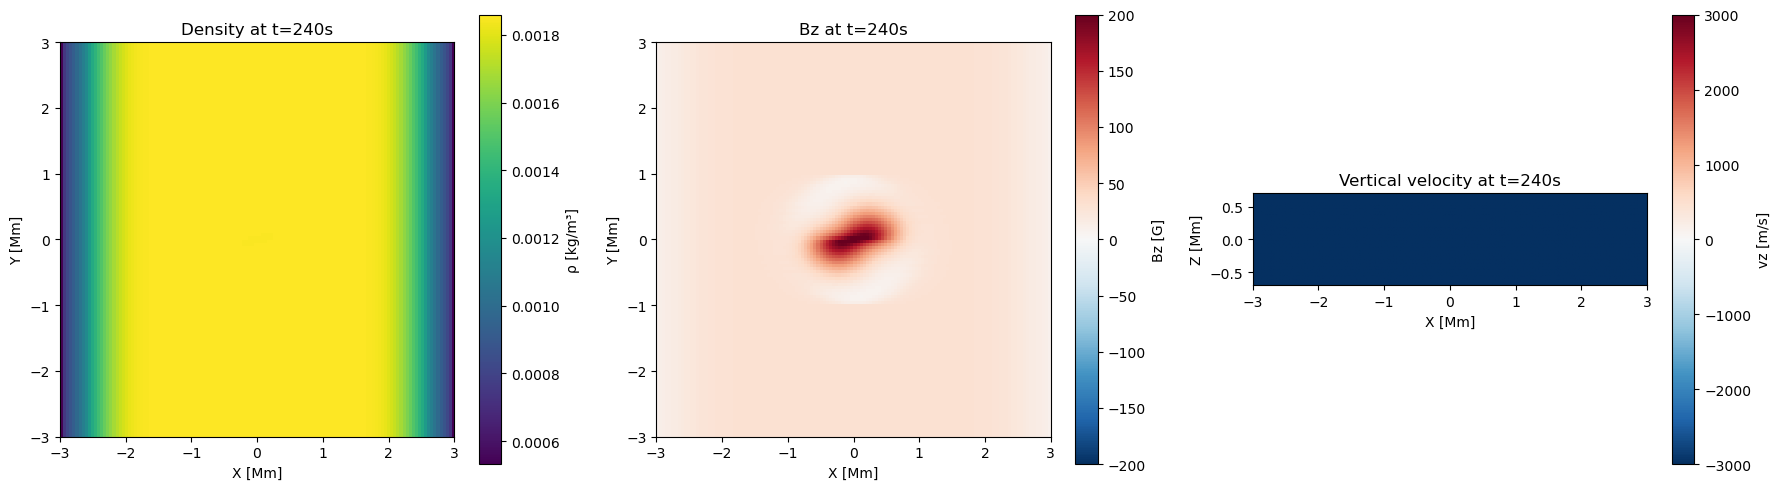

t =    360.0 s  |  Step   1481
  ρ: [4.00e-06, 2.22e-01] kg/m³
  |v|: [42851.3, 49884.0] m/s
  |B|: [1.0, 230.5] G


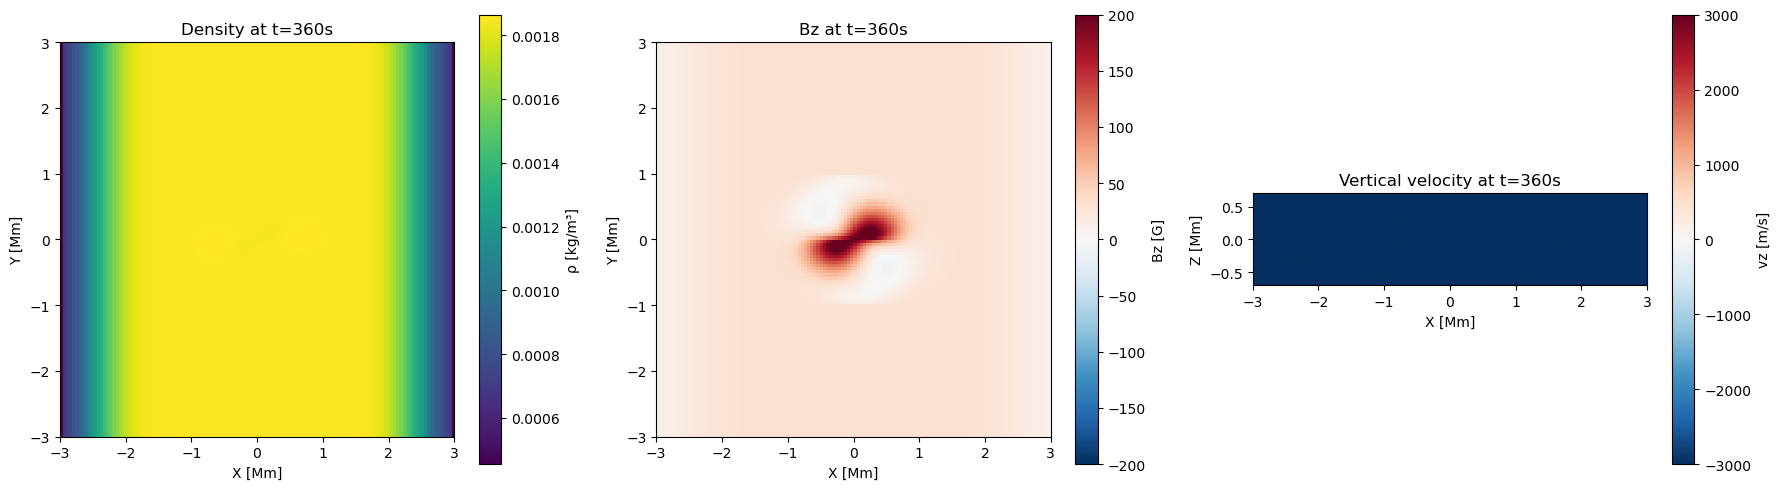

t =    480.0 s  |  Step   2355
  ρ: [3.47e-06, 2.24e-01] kg/m³
  |v|: [56722.8, 66199.2] m/s
  |B|: [0.6, 267.9] G


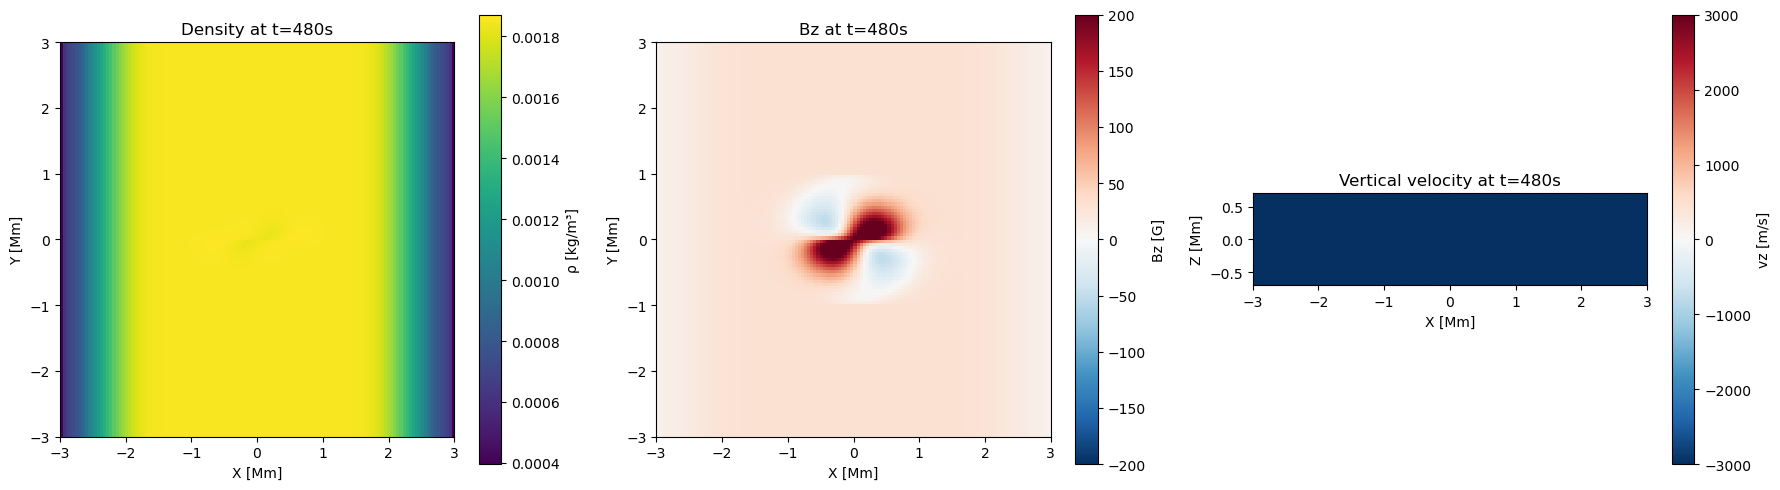

t =    600.0 s  |  Step   3460
  ρ: [3.23e-06, 2.25e-01] kg/m³
  |v|: [70625.9, 82579.5] m/s
  |B|: [0.4, 321.8] G


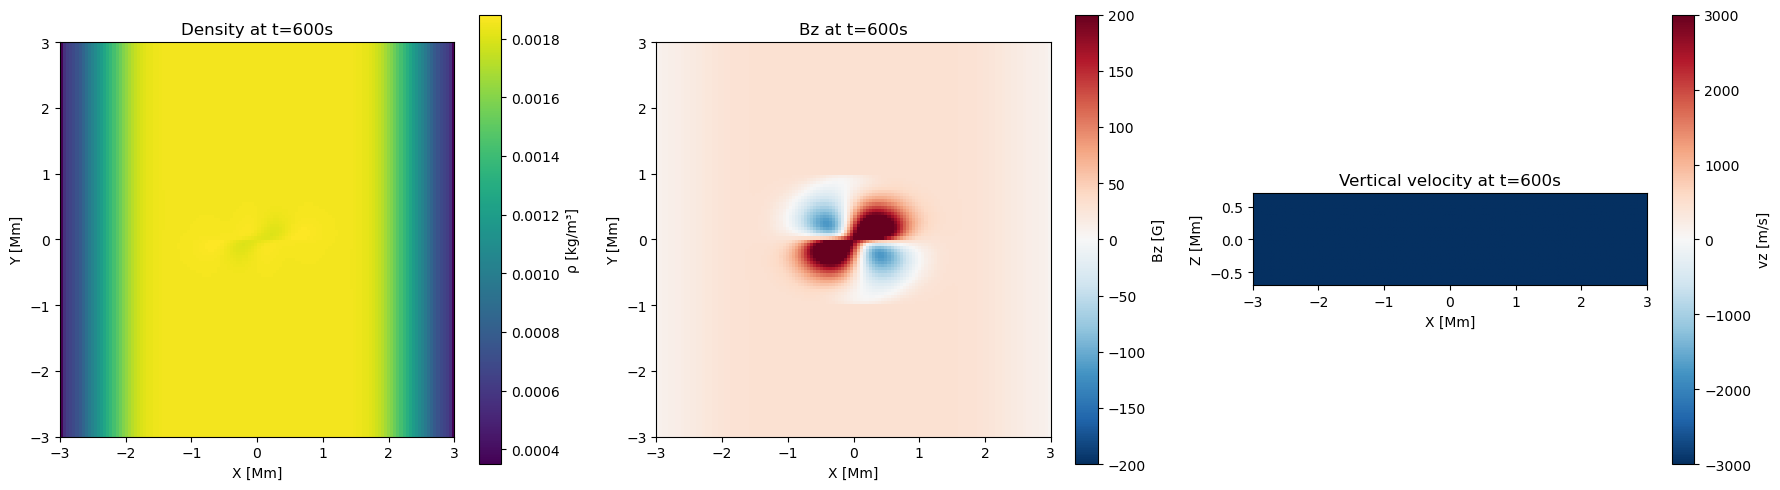

t =    720.0 s  |  Step   4802
  ρ: [3.07e-06, 2.27e-01] kg/m³
  |v|: [84525.2, 99008.2] m/s
  |B|: [0.3, 383.0] G


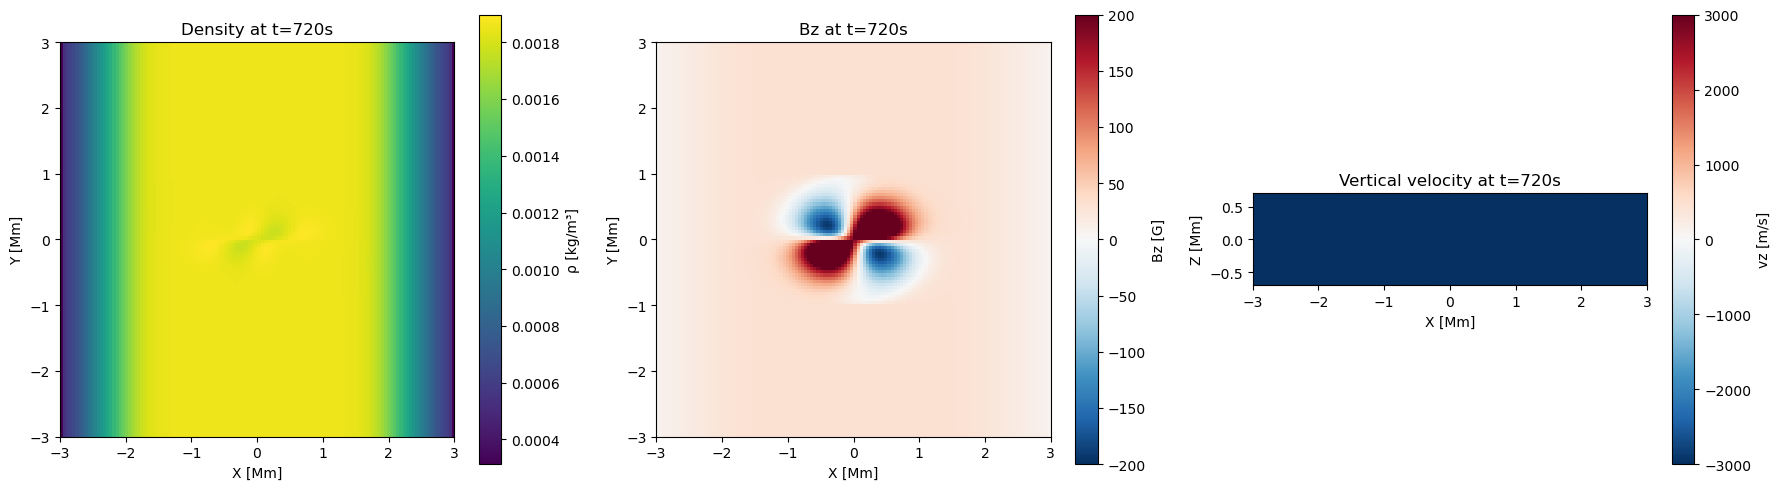

t =    840.0 s  |  Step   6388
  ρ: [2.94e-06, 2.28e-01] kg/m³
  |v|: [98370.5, 115511.3] m/s
  |B|: [0.2, 455.0] G


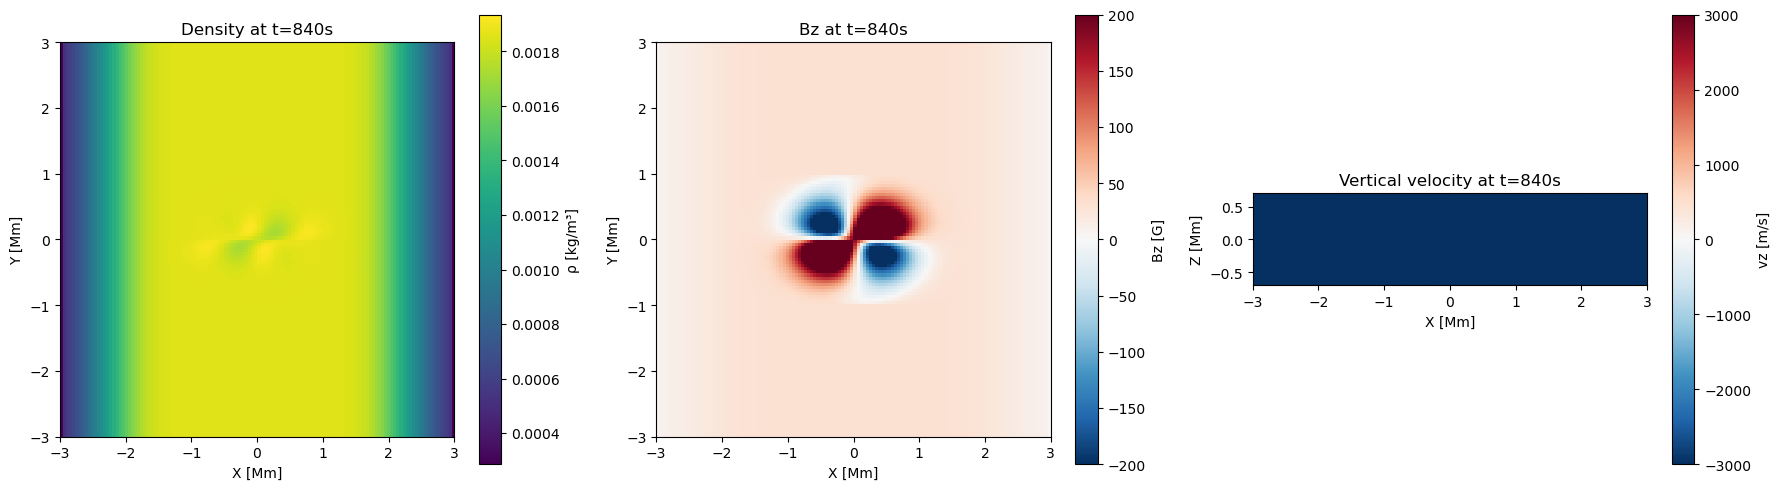

t =    960.0 s  |  Step   8221
  ρ: [2.84e-06, 2.29e-01] kg/m³
  |v|: [112214.7, 132026.3] m/s
  |B|: [0.2, 532.4] G


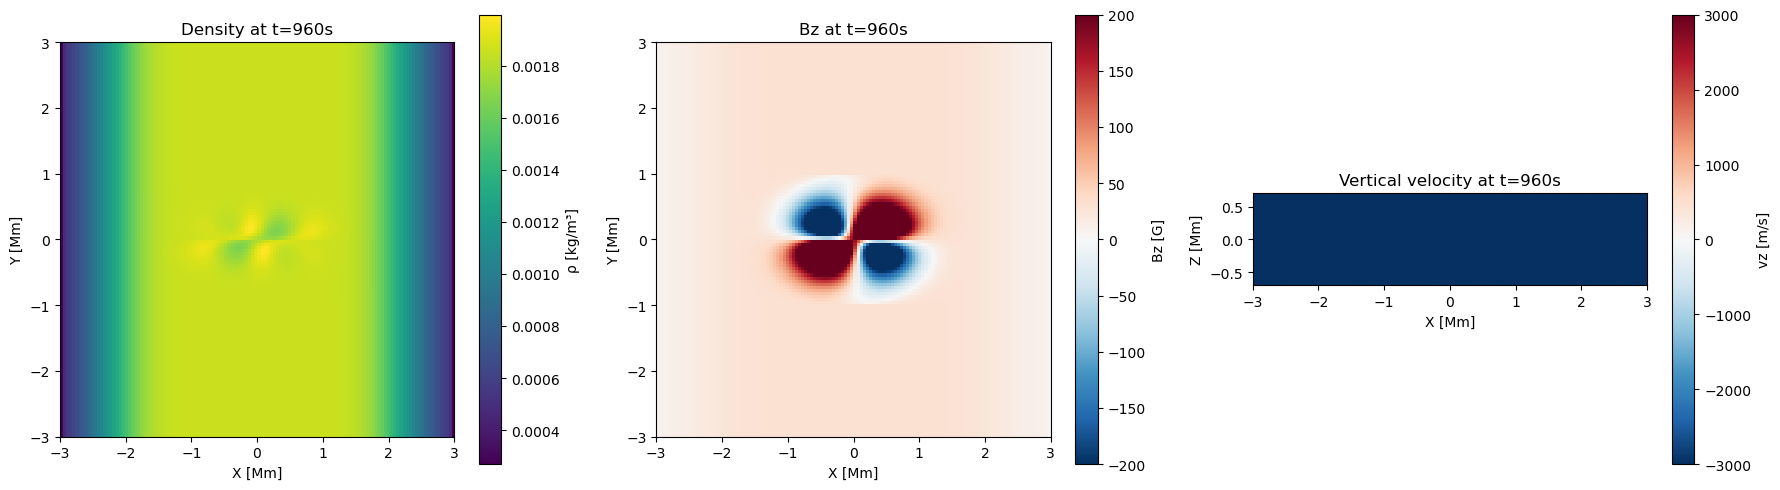

t =   1080.0 s  |  Step  10302
  ρ: [2.77e-06, 2.29e-01] kg/m³
  |v|: [126106.2, 148553.5] m/s
  |B|: [0.1, 616.8] G


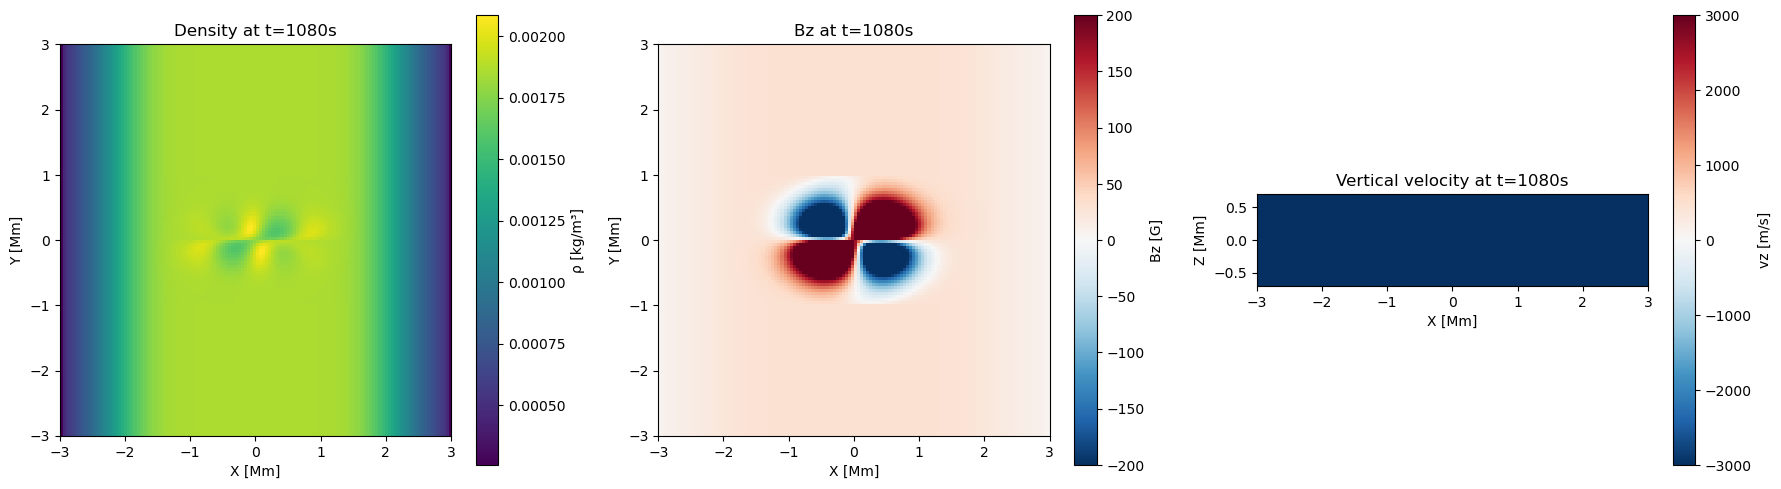

t =   1200.0 s  |  Step  12631
  ρ: [2.56e-06, 2.30e-01] kg/m³
  |v|: [140002.0, 165087.7] m/s
  |B|: [0.1, 704.6] G


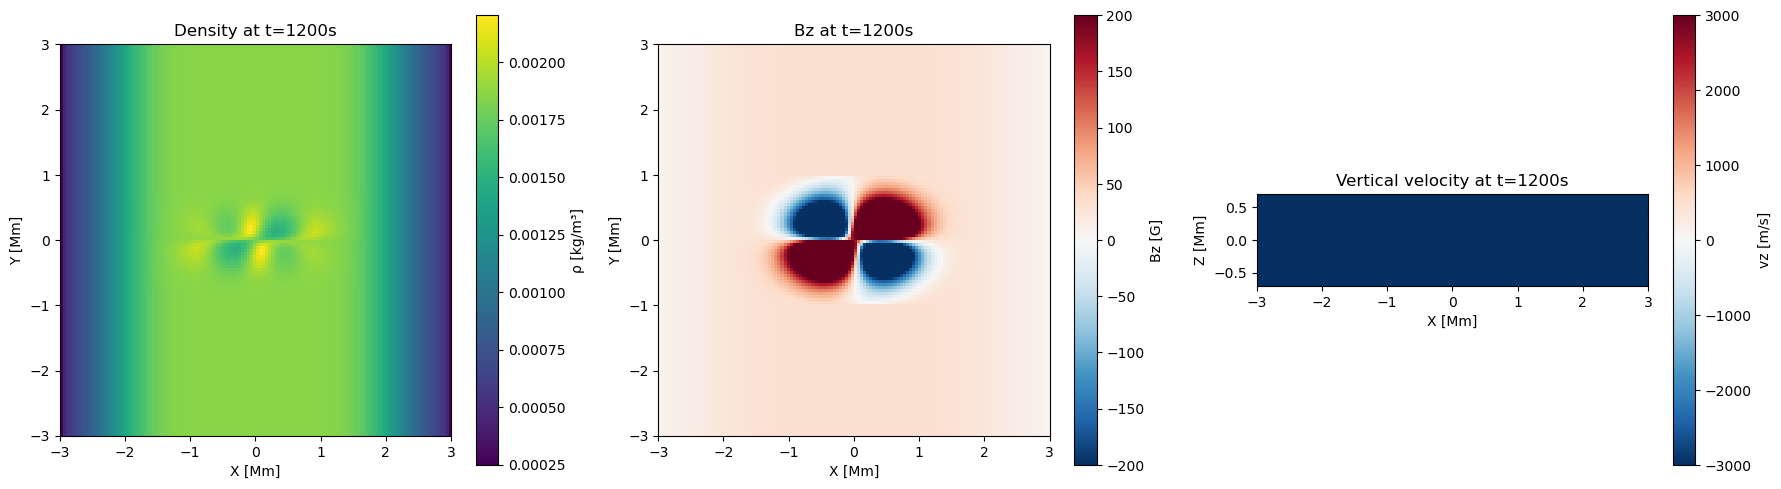

Simulation completed in 481737.1 seconds


In [6]:
# Advanced Solar MHD Simulation - Professional Implementation

import numpy as np
import matplotlib.pyplot as plt
import time

# Physical constants
gamma = 5.0/3.0
mu0 = 4.0*np.pi*1e-7
kB = 1.380649e-23
mH = 1.6735575e-27
g_sun = 274.0
c_light = 2.99792458e8

# Grid parameters
nx, ny, nz = 128, 128, 64
nghosts = 2
nxg, nyg, nzg = nx + 2*nghosts, ny + 2*nghosts, nz + 2*nghosts

# Domain parameters
Lx, Ly, Lz = 6e6, 6e6, 1.4e6
dx, dy, dz = Lx/nx, Ly/ny, Lz/nz

# Time parameters
t_end = 1200.0
dt_output = 120.0
cfl = 0.4

# Coordinate arrays
x = np.linspace(-Lx/2, Lx/2, nx)
y = np.linspace(-Ly/2, Ly/2, ny)
z = np.linspace(-Lz/2, Lz/2, nz)

# State arrays
U = np.zeros((8, nxg, nyg, nzg))
U_new = np.zeros((8, nxg, nyg, nzg))
W = np.zeros((8, nxg, nyg, nzg))

def initialize_atmosphere():
    H_scale = 150e3
    rho_base = 2e-3
    T_base = 5800.0
    B_base = 0.01

    for k in range(nghosts, nzg - nghosts):
        kk = k - nghosts
        z_coord = z[kk]

        rho_z = rho_base * np.exp(-z_coord / H_scale)
        T_z = T_base - 1000.0 * z_coord / H_scale
        T_z = max(T_z, 3500.0)

        e_int = 1.5 * kB * T_z / (0.6 * mH)

        for i in range(nghosts, nxg - nghosts):
            for j in range(nghosts, nyg - nghosts):
                U[0, i, j, k] = rho_z
                U[4, i, j, k] = rho_z * e_int

    np.random.seed(42)
    for k in range(nghosts, nzg - nghosts):
        kk = k - nghosts
        if z[kk] < 0:
            for i in range(nghosts, nxg - nghosts):
                for j in range(nghosts, nyg - nghosts):
                    ii, jj = i - nghosts, j - nghosts
                    x_coord, y_coord = x[ii], y[jj]

                    perturbation = 0.02 * np.sin(2*np.pi*x_coord/Lx) * np.sin(2*np.pi*y_coord/Ly)
                    perturbation += 0.01 * np.sin(4*np.pi*x_coord/Lx) * np.cos(4*np.pi*y_coord/Ly)

                    U[0, i, j, k] *= (1.0 + perturbation)

    for k in range(nghosts, nzg - nghosts):
        for i in range(nghosts, nxg - nghosts):
            for j in range(nghosts, nyg - nghosts):
                ii, jj = i - nghosts, j - nghosts
                x_coord, y_coord = x[ii], y[jj]

                r = np.sqrt(x_coord**2 + y_coord**2)
                phi = np.arctan2(y_coord, x_coord)

                flux_radius = 0.5e6
                if r < 2.0 * flux_radius:
                    strength = B_base * 2.0 * np.exp(-r**2 / flux_radius**2)
                    U[5, i, j, k] = strength * 0.1 * np.sin(phi)
                    U[6, i, j, k] = strength * 0.1 * np.cos(phi)
                    U[7, i, j, k] = strength * (1.0 + 0.3 * np.cos(2*phi))
                else:
                    U[5, i, j, k] = 0.0
                    U[6, i, j, k] = 0.0
                    U[7, i, j, k] = B_base * 0.3

def update_primitives():
    rho = np.maximum(U[0], 1e-12)
    mx, my, mz = U[1], U[2], U[3]
    E = U[4]
    Bx, By, Bz = U[5], U[6], U[7]

    vx = mx / rho
    vy = my / rho
    vz = mz / rho

    e_kinetic = 0.5 * rho * (vx**2 + vy**2 + vz**2)
    e_magnetic = (Bx**2 + By**2 + Bz**2) / (2 * mu0)
    e_internal = np.maximum((E - e_kinetic - e_magnetic) / rho, 1e6)

    pressure = (gamma - 1) * rho * e_internal

    W[0] = rho
    W[1], W[2], W[3] = vx, vy, vz
    W[4] = pressure
    W[5], W[6], W[7] = Bx, By, Bz

def mp5_reconstruction(q):
    n = len(q)
    qL = np.zeros(n)
    qR = np.zeros(n)

    for i in range(2, n-2):
        qm2, qm1, qi, qp1, qp2 = q[i-2], q[i-1], q[i], q[i+1], q[i+2]

        qL_temp = (2*qm2 - 13*qm1 + 47*qi + 27*qp1 - 3*qp2) / 60.0
        qR_temp = (-3*qm2 + 27*qm1 + 47*qi - 13*qp1 + 2*qp2) / 60.0

        qmin = min(qm1, qi, qp1)
        qmax = max(qm1, qi, qp1)

        qL[i] = max(qmin, min(qmax, qL_temp))
        qR[i] = max(qmin, min(qmax, qR_temp))

    qL[0], qL[1] = q[0], q[1]
    qR[0], qR[1] = q[0], q[1]
    qL[-2], qL[-1] = q[-2], q[-1]
    qR[-2], qR[-1] = q[-2], q[-1]

    return qL, qR

def mhd_flux(W_state):
    rho, vx, vy, vz, p, Bx, By, Bz = W_state

    v2 = vx**2 + vy**2 + vz**2
    B2 = Bx**2 + By**2 + Bz**2

    ptot = p + B2 / (2 * mu0)
    E_total = p / (gamma - 1) + 0.5 * rho * v2 + B2 / (2 * mu0)

    F = np.zeros(8)
    F[0] = rho * vx
    F[1] = rho * vx**2 + ptot - Bx**2 / mu0
    F[2] = rho * vx * vy - Bx * By / mu0
    F[3] = rho * vx * vz - Bx * Bz / mu0
    F[4] = (E_total + ptot) * vx - (vx*Bx + vy*By + vz*Bz) * Bx / mu0
    F[5] = 0.0
    F[6] = By * vx - vy * Bx
    F[7] = Bz * vx - vz * Bx

    return F

def primitive_to_conservative(W_state):
    rho, vx, vy, vz, p, Bx, By, Bz = W_state

    v2 = vx**2 + vy**2 + vz**2
    B2 = Bx**2 + By**2 + Bz**2

    U_cons = np.zeros(8)
    U_cons[0] = rho
    U_cons[1] = rho * vx
    U_cons[2] = rho * vy
    U_cons[3] = rho * vz
    U_cons[4] = p / (gamma - 1) + 0.5 * rho * v2 + B2 / (2 * mu0)
    U_cons[5] = Bx
    U_cons[6] = By
    U_cons[7] = Bz

    return U_cons

def hlld_riemann_solver(WL, WR):
    rhoL, vxL, vyL, vzL, pL, BxL, ByL, BzL = WL
    rhoR, vxR, vyR, vzR, pR, BxR, ByR, BzR = WR

    B2L = BxL**2 + ByL**2 + BzL**2
    B2R = BxR**2 + ByR**2 + BzR**2

    csL = np.sqrt(gamma * pL / rhoL)
    csR = np.sqrt(gamma * pR / rhoR)

    caL = np.sqrt(B2L / (mu0 * rhoL))
    caR = np.sqrt(B2R / (mu0 * rhoR))

    cfL = np.sqrt(0.5 * (csL**2 + caL**2 + np.sqrt((csL**2 + caL**2)**2 - 4*csL**2*BxL**2/(mu0*rhoL))))
    cfR = np.sqrt(0.5 * (csR**2 + caR**2 + np.sqrt((csR**2 + caR**2)**2 - 4*csR**2*BxR**2/(mu0*rhoR))))

    cfL = min(cfL, c_light/100)
    cfR = min(cfR, c_light/100)

    S_L = min(vxL - cfL, vxR - cfR)
    S_R = max(vxL + cfL, vxR + cfR)

    if S_L >= 0:
        return mhd_flux(WL)
    elif S_R <= 0:
        return mhd_flux(WR)
    else:
        FL = mhd_flux(WL)
        FR = mhd_flux(WR)
        UL = primitive_to_conservative(WL)
        UR = primitive_to_conservative(WR)

        return (S_R * FL - S_L * FR + S_L * S_R * (UR - UL)) / (S_R - S_L)

def compute_timestep():
    update_primitives()

    rho = W[0, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    vx = W[1, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    vy = W[2, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    vz = W[3, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    p = W[4, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    Bx = W[5, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    By = W[6, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    Bz = W[7, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]

    cs = np.sqrt(gamma * np.maximum(p, 1e-10) / rho)
    B_mag = np.sqrt(Bx**2 + By**2 + Bz**2)
    ca = B_mag / np.sqrt(mu0 * rho)

    v_max = np.abs(vx) + np.abs(vy) + np.abs(vz) + cs + ca

    dt_cfl = cfl * min(dx, dy, dz) / np.max(v_max)

    return min(dt_cfl, 1.0)

def apply_boundary_conditions():
    U[:, :nghosts, :, :] = U[:, -2*nghosts:-nghosts, :, :]
    U[:, -nghosts:, :, :] = U[:, nghosts:2*nghosts, :, :]
    U[:, :, :nghosts, :] = U[:, :, -2*nghosts:-nghosts, :]
    U[:, :, -nghosts:, :] = U[:, :, nghosts:2*nghosts, :]

    for k in range(nghosts):
        U[:, :, :, k] = U[:, :, :, nghosts]
        U[:, :, :, nzg-1-k] = U[:, :, :, nzg-nghosts-1]

    U[3, :, :, :nghosts] = 0.0
    U[3, :, :, -nghosts:] = 0.0

def compute_fluxes():
    flux_x = np.zeros((8, nxg+1, nyg, nzg))

    for j in range(nghosts, nyg - nghosts):
        for k in range(nghosts, nzg - nghosts):
            W_slice = W[:, :, j, k]

            WL_interfaces = np.zeros((8, nxg))
            WR_interfaces = np.zeros((8, nxg))

            for var in range(8):
                qL, qR = mp5_reconstruction(W_slice[var])
                WL_interfaces[var] = qL
                WR_interfaces[var] = qR

            for i in range(nghosts, nxg - nghosts + 1):
                WL_state = WR_interfaces[:, i-1] if i > 0 else WL_interfaces[:, i-1]
                WR_state = WL_interfaces[:, i] if i < nxg else WR_interfaces[:, i]

                flux_x[:, i, j, k] = hlld_riemann_solver(WL_state, WR_state)

    return flux_x

def add_source_terms(dt):
    rho_interior = U[0, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]

    U_new[3, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts] -= dt * rho_interior * g_sun

def time_step(dt):
    U_0 = U.copy()

    update_primitives()
    apply_boundary_conditions()

    flux_x = compute_fluxes()

    for i in range(nghosts, nxg - nghosts):
        U_new[:, i, :, :] = U[:, i, :, :] - dt/dx * (flux_x[:, i+1, :, :] - flux_x[:, i, :, :])

    add_source_terms(dt)

    U[:] = 0.5 * (U_0 + U_new)

def output_diagnostics(t, step_count):
    update_primitives()

    rho = W[0, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    vx = W[1, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    vy = W[2, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    vz = W[3, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    p = W[4, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    Bx = W[5, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    By = W[6, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]
    Bz = W[7, nghosts:-nghosts, nghosts:-nghosts, nghosts:-nghosts]

    v_mag = np.sqrt(vx**2 + vy**2 + vz**2)
    B_mag = np.sqrt(Bx**2 + By**2 + Bz**2) * 1e4

    print(f"t = {t:8.1f} s  |  Step {step_count:6d}")
    print(f"  ρ: [{np.min(rho):.2e}, {np.max(rho):.2e}] kg/m³")
    print(f"  |v|: [{np.min(v_mag):.1f}, {np.max(v_mag):.1f}] m/s")
    print(f"  |B|: [{np.min(B_mag):.1f}, {np.max(B_mag):.1f}] G")

def create_visualization(t):
    update_primitives()

    mid_z = nz // 2 + nghosts
    mid_x = nx // 2 + nghosts

    rho_xy = W[0, nghosts:-nghosts, nghosts:-nghosts, mid_z]
    Bz_xy = W[7, nghosts:-nghosts, nghosts:-nghosts, mid_z] * 1e4
    vz_xz = W[3, nghosts:-nghosts, mid_x, nghosts:-nghosts]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    extent_xy = [-Lx/2e6, Lx/2e6, -Ly/2e6, Ly/2e6]
    extent_xz = [-Lx/2e6, Lx/2e6, -Lz/2e6, Lz/2e6]

    im1 = ax1.imshow(rho_xy.T, origin='lower', extent=extent_xy, cmap='viridis')
    ax1.set_title(f'Density at t={t:.0f}s')
    ax1.set_xlabel('X [Mm]')
    ax1.set_ylabel('Y [Mm]')
    plt.colorbar(im1, ax=ax1, label='ρ [kg/m³]')

    im2 = ax2.imshow(Bz_xy.T, origin='lower', extent=extent_xy, cmap='RdBu_r', vmin=-200, vmax=200)
    ax2.set_title(f'Bz at t={t:.0f}s')
    ax2.set_xlabel('X [Mm]')
    ax2.set_ylabel('Y [Mm]')
    plt.colorbar(im2, ax=ax2, label='Bz [G]')

    im3 = ax3.imshow(vz_xz.T, origin='lower', extent=extent_xz, cmap='RdBu_r', vmin=-3000, vmax=3000)
    ax3.set_title(f'Vertical velocity at t={t:.0f}s')
    ax3.set_xlabel('X [Mm]')
    ax3.set_ylabel('Z [Mm]')
    plt.colorbar(im3, ax=ax3, label='vz [m/s]')

    plt.tight_layout()
    plt.show()

def main_simulation():
    print("Solar MHD Simulation Starting")
    print(f"Grid: {nx} x {ny} x {nz}")
    print(f"Domain: {Lx/1e6:.1f} x {Ly/1e6:.1f} x {Lz/1e6:.1f} Mm")
    print(f"Resolution: {dx/1e3:.1f} x {dy/1e3:.1f} x {dz/1e3:.1f} km")

    initialize_atmosphere()

    t = 0.0
    step_count = 0
    next_output = dt_output

    start_time = time.time()

    while t < t_end:
        dt = compute_timestep()
        dt = min(dt, next_output - t)

        time_step(dt)

        t += dt
        step_count += 1

        if t >= next_output - 1e-10:
            output_diagnostics(t, step_count)
            create_visualization(t)
            next_output += dt_output

    total_time = time.time() - start_time
    print(f"Simulation completed in {total_time:.1f} seconds")

main_simulation()

In [2]:
pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 7.8 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 7.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 9.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 9.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


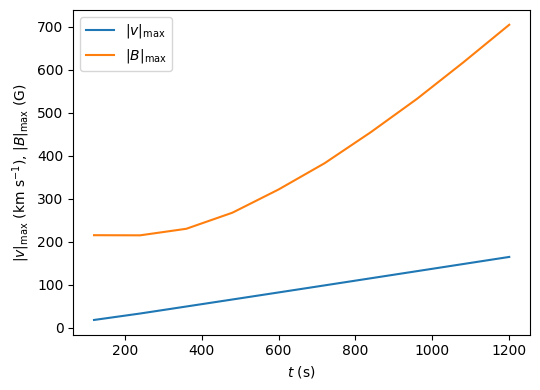

In [5]:
import numpy as np
import matplotlib.pyplot as plt

t = np.array([120, 240, 360, 480, 600, 720, 840, 960, 1080, 1200])
vmax = np.array([18617.9, 33602.8, 49884.0, 66199.2, 82579.5,
                 99008.2, 115511.3, 132026.3, 148553.5, 165087.7]) / 1e3
Bmax = np.array([215.6, 215.3, 230.5, 267.9, 321.8,
                 383.0, 455.0, 532.4, 616.8, 704.6])

plt.figure(figsize=(5.5, 4))
plt.plot(t, vmax, label=r'$|v|_{\max}$')
plt.plot(t, Bmax, label=r'$|B|_{\max}$')
plt.xlabel(r'$t$ (s)')
plt.ylabel(r'$|v|_{\max}$ (km s$^{-1}$), $|B|_{\max}$ (G)')
plt.legend()
plt.tight_layout()
plt.savefig('3d_extrema_evolution.png', dpi=300)